# Setup

In [166]:
import warnings
import functools

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import h5py
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import cross_val_score

from data import MET_Data

In [227]:
def get_irreducible_mask(swc_parents):
    degrees = np.zeros_like(swc_parents)
    has_parent = (swc_parents != -1)
    degrees[has_parent] += 1
    (parent_idx, num_children) = np.unique(swc_parents[has_parent], return_counts = True)
    degrees[parent_idx] += num_children
    irreducible_mask = (degrees != 2)
    return irreducible_mask

def build_histograms(swc_coords, swc_types, swc_parents, r_edges, z_edges, irreducible = False):
    structure_groupings = {"axon": [2], "basal": [3], "apical": [4]}
    disk_areas = np.pi*(r_edges[1:]**2 - r_edges[:-1]**2)
    disk_areas = disk_areas / disk_areas.max()
    histograms = {}
    for (coords, types, parents) in zip(swc_coords, swc_types, swc_parents):
        is_soma = (types == 1)
        centered_xy = coords[:, :2] - coords[is_soma, :2].mean(0)
        r = np.square(centered_xy).sum(1)**0.5
        centered_z = coords[:, 2] - 0.5
        irred_mask = get_irreducible_mask(parents) if irreducible else True
        for (structure, struct_ids) in structure_groupings.items():
            is_target = np.isin(types, struct_ids) & irred_mask
            (target_z, target_r) = (centered_z[is_target], r[is_target])
            hist = np.histogram2d(target_z, target_r, [z_edges, r_edges])[0]
            histograms.setdefault(structure, []).append(hist / disk_areas)
    return histograms

def get_arbors(swc_data, classes, r_edges, z_edges, combine_arbors = False, irreducible = False):
    histograms = build_histograms(swc_data["swc_conf"], swc_data["swc_types"], swc_data["swc_parents"], 
                                  r_edges = r_edges, z_edges = z_edges, irreducible = irreducible)
    arbor_types = {"exc": (("apical", 2), ("basal", 3)), "inh": (("axon", 0), ("basal", 1))}
    morphs = []
    for (sp_idx, neuron_class) in enumerate(classes):
        blank = None
        for (arbor, index) in arbor_types[neuron_class]:
            hist_array = histograms[arbor][sp_idx]
            if blank is None:
                blank = np.zeros(hist_array.shape + (4,))
            blank[..., index] = hist_array
        if combine_arbors:
            blank = blank.sum(-1)
        morphs.append(blank)
    morphs = np.stack(morphs, 0)
    return morphs

def build_sholl_vectors(swc_coords, swc_types, swc_parents, max_radius, num_steps):
    structure_groupings = {"axon": [2], "basal": [3], "apical": [4]}
    sholl_vectors = {}
    for (coords, parents, types) in zip(swc_coords, swc_parents, swc_types):
        coords = coords - coords[types == 1].mean(0)
        has_parent = (parents != -1)
        radii = np.square(coords).sum(-1)**0.5
        query_radii = np.linspace(0, max_radius, num_steps)
        for (structure, struct_ids) in structure_groupings.items():
            is_valid = np.isin(types, struct_ids + [1]) & has_parent
            segments = np.stack([radii[parents][is_valid], radii[is_valid]], -1)
            is_larger = segments[..., None] > query_radii[None, None]
            is_crossing = is_larger[:, 0] ^ is_larger[:, 1]
            sholl_vectors.setdefault(structure, []).append(np.sum(is_crossing, 0))
    return sholl_vectors

def get_sholl(swc_data, classes, max_radius, num_steps, combine_arbors = False):
    sholl_vectors = build_sholl_vectors(swc_data["swc_upright"], swc_data["swc_types"], 
                                        swc_data["swc_parents"], max_radius, num_steps)
    arbor_types = {"exc": (("apical", 2), ("basal", 3)), "inh": (("axon", 0), ("basal", 1))}
    sholl_typed = []
    for (sp_idx, neuron_class) in enumerate(classes):
        blank = None
        for (arbor, index) in arbor_types[neuron_class]:
            sholl_vec = sholl_vectors[arbor][sp_idx]
            if blank is None:
                blank = np.zeros(sholl_vec.shape + (4,))
            blank[..., index] = sholl_vec
        if combine_arbors:
            blank = blank.sum(-1)
        sholl_typed.append(blank)
    sholl_typed = np.stack(sholl_typed, 0)
    return sholl_typed

def get_morphometric(specimen_ids, met_data):
    data = met_data.get_specimens(specimen_ids, outputs = ["morphometric"])
    return data["morphometric"]

def get_h5_data(h5_file, data_keys):
    specimens = h5_file["specimens"][:].astype(str)
    h5_data = {}
    valid_specimens = []
    for (sp_idx, sp_id) in enumerate(specimens):
        valid = False
        for key in data_keys:
            dataset = h5_file[key]
            sp_key_idx = np.where(dataset["sp_idx"][:] == sp_idx)[0]
            if sp_key_idx.size > 0:
                valid = True
                data = np.reshape(dataset["data"][sp_key_idx[0]], dataset["shape"][sp_key_idx[0]])
                h5_data.setdefault(key, []).append(data)
        if valid:
            valid_specimens.append(sp_id)
    return (specimens, h5_data)

In [147]:
data_paths = {"patchseq": "../data/patchseq.hdf5", "sholl": "../data/sholl_0x.hdf5"}
data_keys = {"logcpm": [["patchseq", "logcpm"]], "pca-ipfx": [["patchseq", "pca-ipfx"]],
             "arbors": [["patchseq", "arbors"]], "morphometric": [["patchseq", "morphometric"]],
             "sholl": [["sholl", "sholl"]]}
met_data = MET_Data(data_paths, **data_keys)
for form in ["logcpm", "pca-ipfx", "arbors", "morphometric", "sholl"]:
    met_data.cache_data(form)
patch_file = h5py.File("/Users/ian.convy/code/arbors/outputs/patchseq.hdf5", "r")
(specimen_ids, swc_data) = get_h5_data(patch_file, ["swc_upright", "swc_conf", "swc_types", "swc_parents"])

Caching logcpm...
Caching pca-ipfx...
Caching arbors...
Caching morphometric...
Caching sholl...


In [228]:
classes = met_data.get_specimens(specimen_ids, outputs = ["class"])["class"]
funcs = {"arbors": functools.partial(get_arbors, swc_data, classes),
         "sholl": functools.partial(get_sholl, swc_data, classes),
         "morphometric": functools.partial(get_morphometric, specimen_ids, met_data)}

# Results

In [241]:
experiments = {
    "120x4x4": [{"type": "arbors", "r_edges": np.linspace(0, 2000, 4 + 1), "z_edges": np.linspace(-0.5, 0.5, 120 + 1), "irreducible": False}],
    "120x4x1": [{"type": "arbors", "r_edges": np.linspace(0, 2000, 4 + 1), "z_edges": np.linspace(-0.5, 0.5, 120 + 1), "combine_arbors": True}],
    "120x4x4_irred": [{"type": "arbors", "r_edges": np.linspace(0, 2000, 4 + 1), "z_edges": np.linspace(-0.5, 0.5, 120 + 1), "irreducible": True}],
    "morphometric": [{"type": "morphometric"}],
    "sholl": [{"type": "sholl", "max_radius": 400, "num_steps": 190}],
    "120x4x4_morph": [{"type": "arbors", "r_edges": np.linspace(0, 2000, 4 + 1), "z_edges": np.linspace(-0.5, 0.5, 120 + 1), "irreducible": False},
                      {"type": "morphometric"}],
    "morph_sholl": [{"type": "sholl", "max_radius": 400, "num_steps": 190},
                    {"type": "morphometric"}],
    "120x4x4_sholl": [{"type": "arbors", "r_edges": np.linspace(0, 2000, 4 + 1), "z_edges": np.linspace(-0.5, 0.5, 120 + 1), "irreducible": False},
                      {"type": "sholl", "max_radius": 400, "num_steps": 190}],
    # **{f"sholl_{max_radius}_{num_steps}": [{"type": "sholl", "max_radius": max_radius, "num_steps": num_steps}, 
    #                                        {"type": "arbors", "r_edges": np.linspace(0, 2000, 4 + 1), "z_edges": np.linspace(-0.5, 0.5, 120 + 1), "irreducible": False}]
    #    for max_radius in np.arange(0, 2100, 100)[1:] for num_steps in np.arange(0, 210, 10)[1:]}
}


In [242]:
target = "cluster_label"
scores = {}

In [243]:
warnings.filterwarnings("ignore", "The least")
for (exp_name, params_list) in experiments.items():
    if exp_name in scores: continue 
    param_specimens = []
    arrays = []
    for params in params_list:
        params = params.copy()
        feat_func = funcs[params.pop("type")]
        feat_arr = feat_func(**params)
        arrays.append(feat_arr.reshape(feat_arr.shape[0], -1))
    combined_mask = functools.reduce(np.logical_and, [~np.isnan(arr).all(-1) for arr in arrays])
    X = np.concatenate([arr[combined_mask] for arr in arrays], -1)
    y = met_data.get_specimens(specimen_ids[combined_mask], outputs = [target])[target]

    print(f"Running {exp_name} ({len(scores) + 1}/{len(experiments)})                  ", end = "\r")
    X = np.nan_to_num(X)
    classifier = RandomForestClassifier()
    scores[exp_name] = cross_val_score(classifier, X, y, cv = 10).mean()


In [244]:
for (exp_name, score) in scores.items():
    print(f"{exp_name}: {score:.4f}")

120x4x4: 0.4104
120x4x1: 0.3424
120x4x4_irred: 0.3647
morphometric: 0.4423
sholl: 0.3560
120x4x4_morph: 0.4199
morph_sholl: 0.4199
120x4x4_sholl: 0.4604


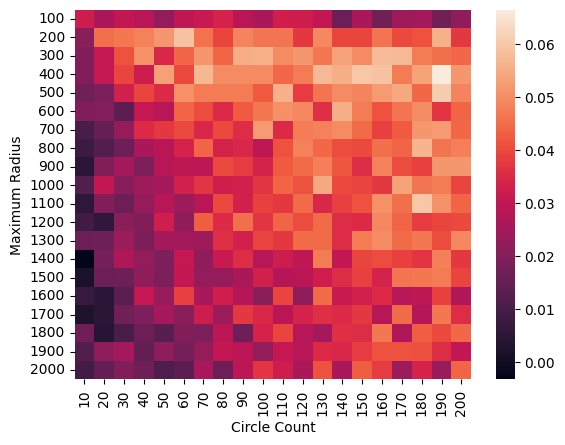

In [249]:
df = pd.DataFrame({
    "Accuracy": [score - 0.405 for score in list(scores_sholl_x4.values())],
    "Maximum Radius": [int(key.split("_")[1]) for key in scores_sholl_x4 if "sholl" in key],
    "Circle Count": [int(key.split("_")[2]) for key in scores_sholl_x4 if "sholl" in key]
})
df_wide = df.pivot_table(index = "Maximum Radius", columns = "Circle Count", values = "Accuracy")
sns.heatmap(df_wide)
plt.show()